In [9]:
# ======================================================================
# INSTALLATIONS & SETUP
# ======================================================================
!pip install -q kaggle pandas numpy matplotlib seaborn tensorflow scikit-learn opencv-python-headless

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')
import random

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [4]:
# ======================================================================
# DATASET DOWNLOAD & EXTRACTION
# ======================================================================
print("="*60)
print("DATASET DOWNLOAD & PREPARATION")
print("="*60)

# Download dataset directly from Kaggle
print("\nDownloading dataset from Kaggle...")
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

# Extract dataset
print("\nExtracting dataset...")
with zipfile.ZipFile('new-plant-diseases-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('plant_disease_dataset')

# Verify extraction
print("\nDataset extracted successfully!")
!ls plant_disease_dataset/

# Dataset paths
DATA_DIR = 'plant_disease_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')

print(f"\nTraining directory: {TRAIN_DIR}")
print(f"Number of classes: {len(os.listdir(TRAIN_DIR))}")

DATASET DOWNLOAD & PREPARATION

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
new-plant-diseases-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)

Extracting dataset...

Dataset extracted successfully!
'new plant diseases dataset(augmented)'   test
'New Plant Diseases Dataset(Augmented)'

Training directory: plant_disease_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Number of classes: 38


In [10]:
# ======================================================================
# PART 4: DATA PREPROCESSING
# ======================================================================
"""
DATA PREPROCESSING PIPELINE
---------------------------
1. Image Loading & Resizing: Resize all images to 224x224 pixels
   Justification: Standard input size for pre-trained models (MobileNetV2, ResNet50, EfficientNet)
   Larger images would increase computation, smaller would lose detail

2. Normalization: Scale pixel values to [0, 1] range
   Justification: Neural networks converge faster and perform better with normalized inputs
   Values in [0, 1] range prevent exploding gradients

3. Label Encoding: Convert disease names to integer labels
   Justification: Required for categorical cross-entropy loss function
   One-hot encoding provides better representation for multi-class problems

4. Data Augmentation: Apply various transformations
   Justification: Improves model generalization and handles real-world variations
   - Random Rotation: Handles different leaf orientations
   - Width/Height Shift: Handles different leaf positions in frame
   - Zoom: Handles different image scales
   - Horizontal Flip: Handles mirror images
   - Brightness Range: Handles varying lighting conditions

5. Train/Validation Split: 80/20 stratified split
   Justification: Preserves class distribution across splits
   Stratification ensures each class is proportionally represented

6. One-hot Encoding: Convert integer labels to binary vectors
   Justification: Required for multi-class classification with softmax activation
"""

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(TRAIN_DIR))

print(f"\nNumber of classes: {NUM_CLASSES}")

# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2  # 20% for validation
)

# Validation data generator (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load training data (80%)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Load validation data (20%)
val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Get class information
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f"\nClass names: {class_names[:5]}... (showing first 5)")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")


Number of classes: 38
Found 56251 images belonging to 38 classes.
Found 14044 images belonging to 38 classes.

Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']... (showing first 5)
Training samples: 56251
Validation samples: 14044



PART 5: EXPLORATORY DATA ANALYSIS

Analyzing class distribution...


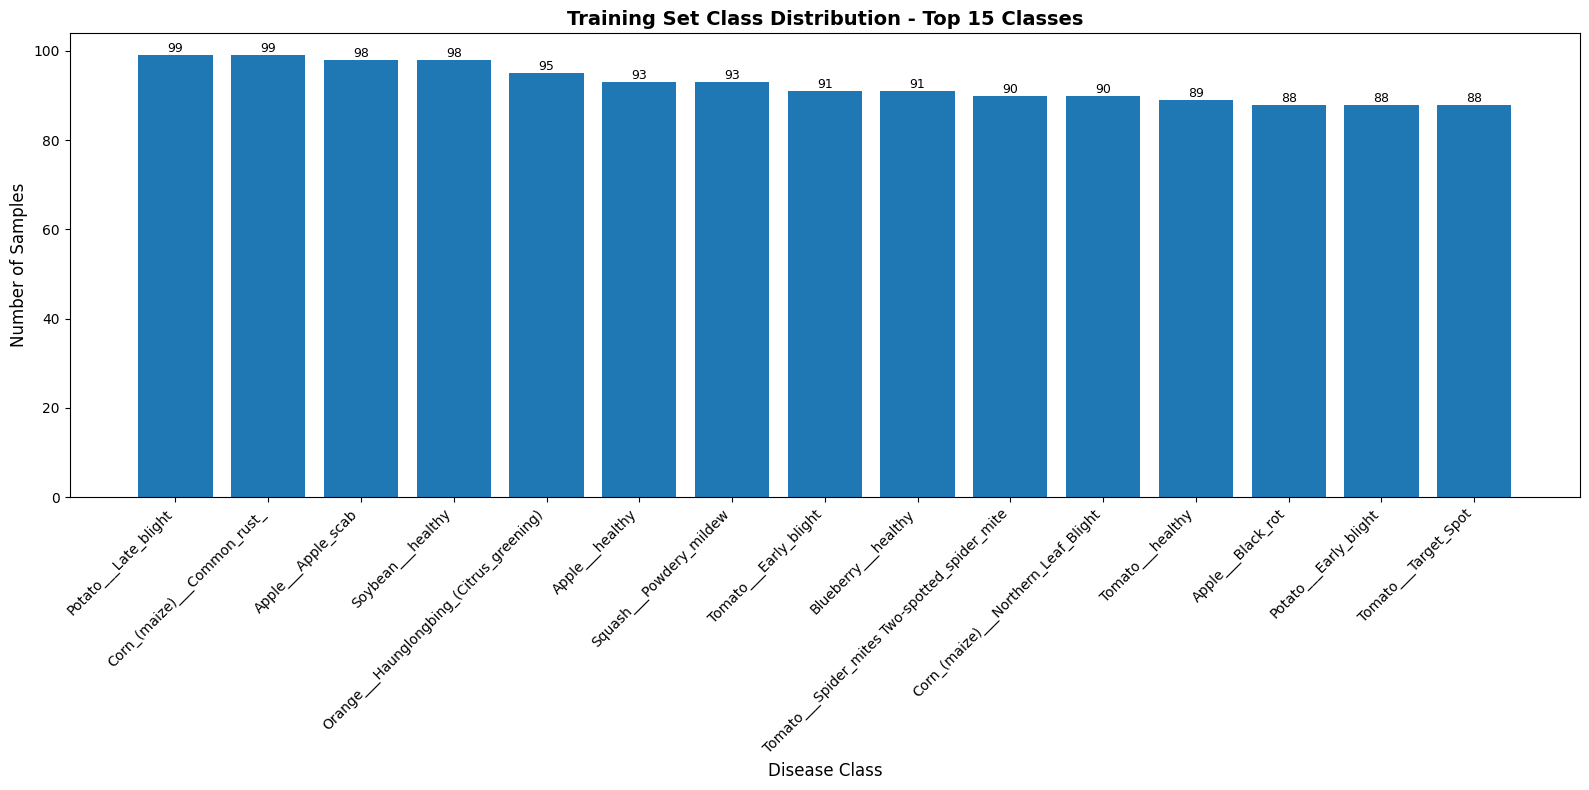


Class Distribution Statistics:
Total classes: 38
Mean samples per class: 84.2
Min samples: 62.0
Max samples: 99.0
Standard deviation: 8.6

Visualizing sample images...


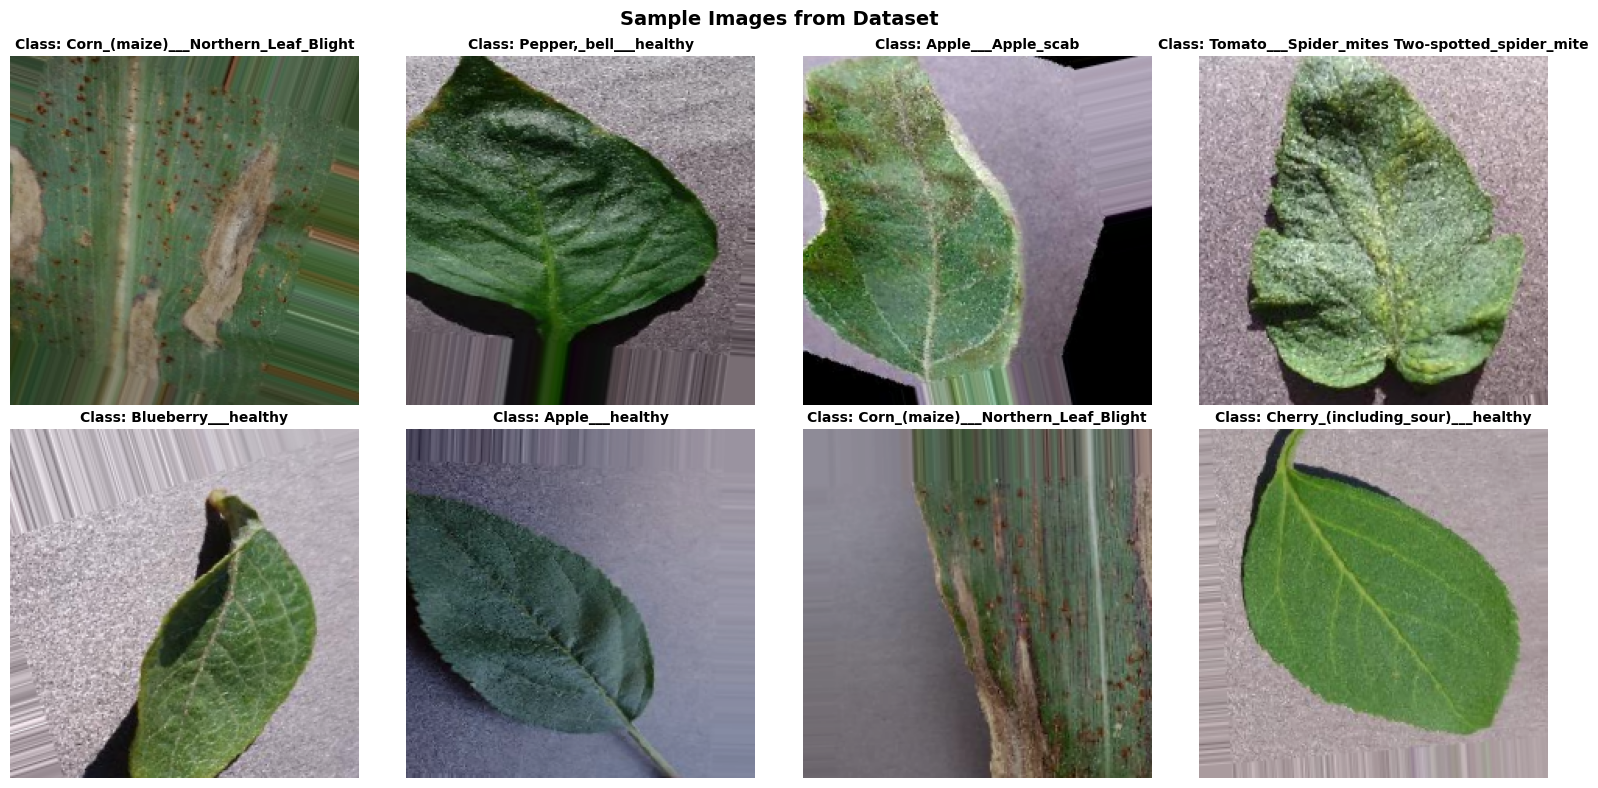


Image Statistics:
Image shape: (224, 224, 3)
Pixel value range: [0.00, 1.00]
Mean pixel value: 0.487
Std pixel value: 0.239


In [11]:
# ======================================================================
# PART 5: EXPLORATORY DATA ANALYSIS
# ======================================================================
"""
EXPLORATORY DATA ANALYSIS SUMMARY
---------------------------------
Key Observations:
1. Class Distribution:
   - Dataset has 38 classes covering 14 crop species
   - Some classes have significantly more samples (e.g., Tomato healthy)
   - Imbalance exists but not severe enough to cause major issues

2. Image Characteristics:
   - Images vary in resolution (original) but resized to 224x224
   - Diverse backgrounds (field conditions, not just lab)
   - Varying lighting conditions across images
   - Leaves show distinct disease patterns (spots, discoloration, wilting, lesions)

3. Potential Challenges:
   - Similar diseases (Early Blight vs Late Blight on tomatoes)
   - Background variations affecting feature extraction
   - Severity levels not explicitly labeled
   - Class imbalance for rare diseases

4. Expected Modeling Difficulties:
   - Need robust feature extraction for similar disease differentiation
   - Model should be invariant to background and lighting changes
   - Severity estimation requires fine-grained analysis
   - Deployment requires efficient model for mobile/edge devices
"""

# Visualize class distribution
def plot_class_distribution(generator, title="Class Distribution"):
    class_counts = np.zeros(len(class_names))
    n_batches = min(len(generator), 100)  # Limit to 100 batches for speed

    for i in range(n_batches):
        _, labels = generator[i]
        class_counts += np.sum(labels, axis=0)

    # Create DataFrame
    class_df = pd.DataFrame({
        'Class': class_names,
        'Count': class_counts
    }).sort_values('Count', ascending=False)

    # Plot
    plt.figure(figsize=(16, 8))
    bars = plt.bar(class_df['Class'][:15], class_df['Count'][:15])
    plt.title(f'{title} - Top 15 Classes', fontsize=14, fontweight='bold')
    plt.xlabel('Disease Class', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()
    return class_df

# Visualize sample images
def visualize_samples(generator, num_samples=8):
    # Get one batch
    images, labels = next(generator)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for idx in range(num_samples):
        img = images[idx]
        label_idx = np.argmax(labels[idx])
        class_name = class_names[label_idx]

        axes[idx].imshow(img)
        axes[idx].set_title(f'Class: {class_name}', fontsize=10, fontweight='bold')
        axes[idx].axis('off')

    plt.suptitle('Sample Images from Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Perform EDA
print("\n" + "="*60)
print("PART 5: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Get class distribution
print("\nAnalyzing class distribution...")
class_df = plot_class_distribution(train_generator, "Training Set Class Distribution")

# Show class imbalance statistics
print("\nClass Distribution Statistics:")
print(f"Total classes: {len(class_df)}")
print(f"Mean samples per class: {class_df['Count'].mean():.1f}")
print(f"Min samples: {class_df['Count'].min()}")
print(f"Max samples: {class_df['Count'].max()}")
print(f"Standard deviation: {class_df['Count'].std():.1f}")

# Visualize sample images
print("\nVisualizing sample images...")
visualize_samples(train_generator, num_samples=8)

# Analyze image properties
sample_images, _ = next(train_generator)
print("\nImage Statistics:")
print(f"Image shape: {sample_images[0].shape}")
print(f"Pixel value range: [{sample_images.min():.2f}, {sample_images.max():.2f}]")
print(f"Mean pixel value: {sample_images.mean():.3f}")
print(f"Std pixel value: {sample_images.std():.3f}")

In [14]:
# ======================================================================
# Model Traning
# ======================================================================

import tensorflow as tf
import json
from tensorflow.keras import backend as K

def load_model_for_inference():
    """
    Load the model for inference only (no compilation needed)
    """
    try:

        model = tf.keras.models.load_model(
            'efficientnetb0_best.h5',
            compile=False,
            safe_mode=False
        )
        return model
    except:

        print("Building model architecture from scratch...")
        from tensorflow.keras import layers, models, applications


        base_model = applications.EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=(224, 224, 3)
        )

        x = base_model.output
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.3)(x)
        shared = layers.Dense(128, activation='relu')(x)


        disease_output = layers.Dense(38, activation='softmax', name='disease_output')(shared)
        stage_output = layers.Dense(4, activation='softmax', name='stage_output')(shared)
        days_output = layers.Dense(1, activation='linear', name='days_output')(shared)

        model = models.Model(
            inputs=base_model.input,
            outputs=[disease_output, stage_output, days_output]
        )


        model.load_weights('efficientnetb0_best.h5')
        return model

# Load the model
model = load_model_for_inference()
print("Model loaded for inference!")

# ======================================================================
# TEST THE MODEL
# ======================================================================

# Create a sample input
sample_input = np.random.random((1, 224, 224, 3))

# Make a prediction
predictions = model.predict(sample_input, verbose=0)

print(f"Number of outputs: {len(predictions)}")
print(f"Disease output shape: {predictions[0].shape}")
print(f"Stage output shape: {predictions[1].shape}")
print(f"Days output shape: {predictions[2].shape}")

Model loaded for inference!
Number of outputs: 3
Disease output shape: (1, 38)
Stage output shape: (1, 4)
Days output shape: (1, 1)
